In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# **Data Awal**

In [ ]:
df = pd.read_csv("basel_temp.csv", parse_dates=["DATE"], index_col="DATE")
y = df["BASEL_temp_mean"]

print(df.head())

            BASEL_temp_mean
DATE                       
2000-01-01              2.9
2000-01-02              3.6
2000-01-03              2.2
2000-01-04              3.9
2000-01-05              6.0


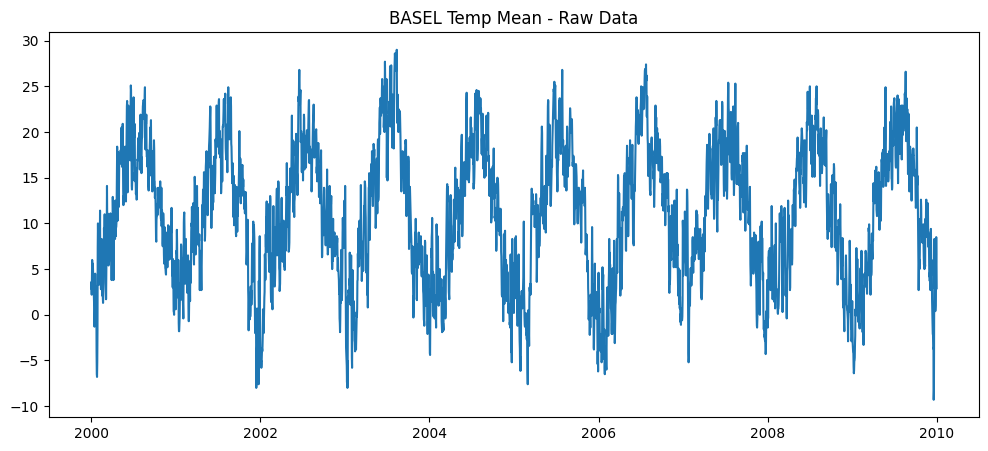

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y)
plt.title("BASEL Temp Mean - Raw Data")
plt.show()

# **CEK MEAN STASIONERITAS**

In [ ]:
from statsmodels.tsa.stattools import adfuller

y = df["BASEL_temp_mean"]

def adf_test(series, title=""):
    print(f"=== ADF Test: {title} ===")
    result = adfuller(series.dropna())
    print("ADF Statistic :", result[0])
    print("p-value        :", result[1])
    print("Critical Values:", result[4])

adf_test(y, "Raw Data")

=== ADF Test: Raw Data ===
ADF Statistic : -4.695208890657525
p-value        : 8.591414050721417e-05
Critical Values: {'1%': np.float64(-3.4321477795421935), '5%': np.float64(-2.8623343588485692), '10%': np.float64(-2.5671928493690377)}


mean sudah stasioner, p-value ADF = 8.59e-05 < 0.05

Rolling Variance Plot

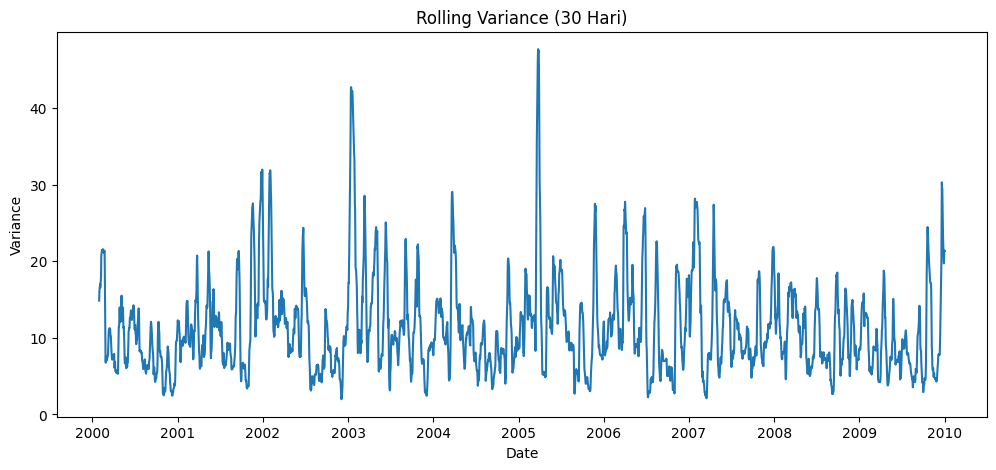

In [ ]:
import matplotlib.pyplot as plt

rolling_var = df["BASEL_temp_mean"].rolling(30).var()

plt.figure(figsize=(12,5))
plt.plot(rolling_var)
plt.title("Rolling Variance (30 Hari)")
plt.xlabel("Date")
plt.ylabel("Variance")
plt.show()


Dari grafik rolling variance:

*   Varians naik–turun sangat jelas
*   Kadang rendah (sekitar 5–10)
*   Kadang tiba-tiba tinggi (20–45)

Ini bukti kuat heteroskedastisitas.

ARCH Test

In [ ]:
from statsmodels.stats.diagnostic import het_arch

arch_result = het_arch(df["BASEL_temp_mean"].dropna())

print("ARCH Test Results:")
print("LM Statistic :", arch_result[0])
print("p-value      :", arch_result[1])
print("F-Statistic  :", arch_result[2])
print("F p-value    :", arch_result[3])


ARCH Test Results:
LM Statistic : 3281.1308293375964
p-value      : 0.0
F-Statistic  : 3285.0264686921037
F p-value    : 0.0


karena p-value = 0, varians tidak stasioner secara ekstrem

# **Transformasi Varians**

Lambda Box-Cox = 1.0143088545347747


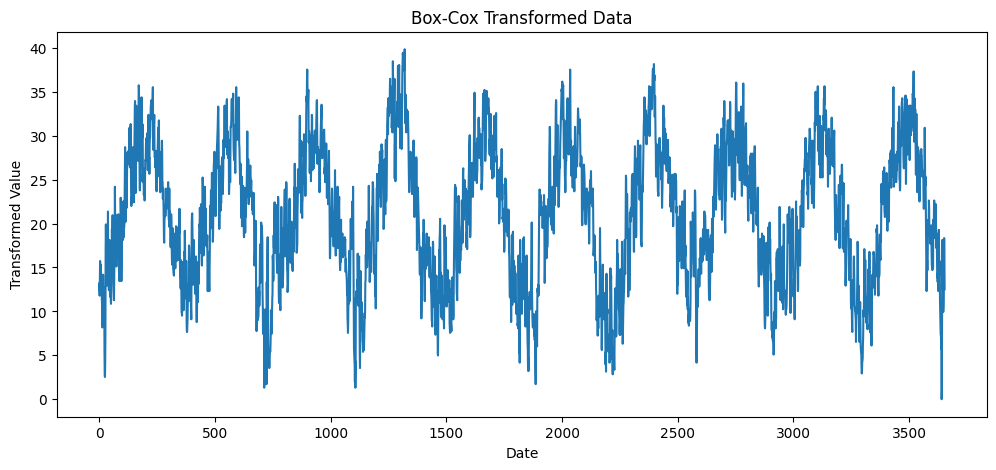

In [ ]:
from scipy.stats import boxcox
import numpy as np
import matplotlib.pyplot as plt

y = df["BASEL_temp_mean"]

y_shift = y - y.min() + 1

y_bc, lam = boxcox(y_shift)

print("Lambda Box-Cox =", lam)
plt.figure(figsize=(12,5))
plt.plot(y_bc)
plt.title("Box-Cox Transformed Data")
plt.xlabel("Date")
plt.ylabel("Transformed Value")
plt.show()

Box–Cox hampir sama dengan transformasi linear (λ = 1), sehingga tidak terlalu butuh transformasi non-linear yang agresif

# **Differencing Setelah Transformasi**

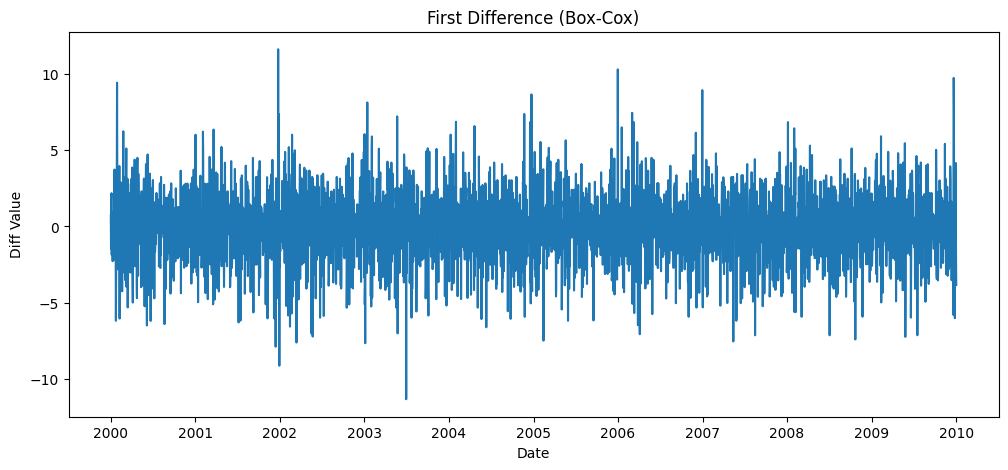

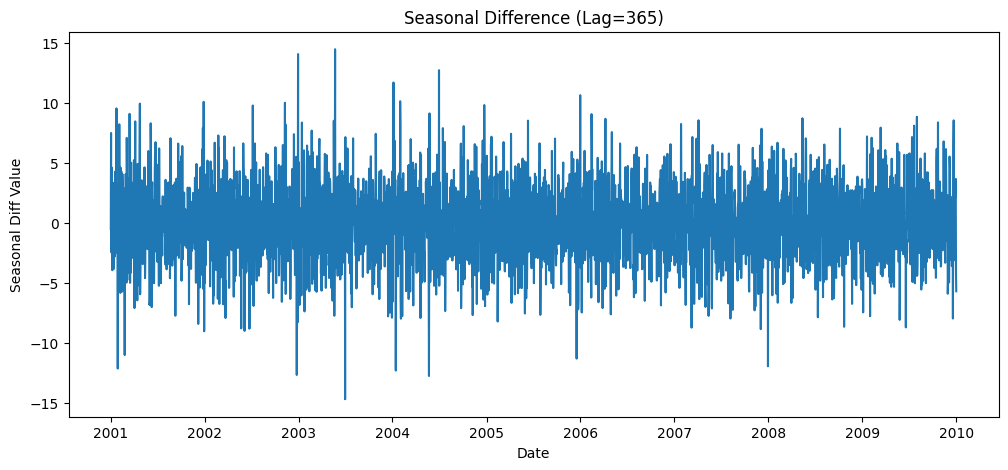

Jumlah data setelah differencing: 3288


In [ ]:
import matplotlib.pyplot as plt

y_bc_series = pd.Series(y_bc, index=df.index)

y_diff1 = y_bc_series.diff()

plt.figure(figsize=(12,5))
plt.plot(y_diff1)
plt.title("First Difference (Box-Cox)")
plt.xlabel("Date")
plt.ylabel("Diff Value")
plt.show()

# 2. Seasonal difference
y_diff_seasonal = y_diff1.diff(365)

plt.figure(figsize=(12,5))
plt.plot(y_diff_seasonal)
plt.title("Seasonal Difference (Lag=365)")
plt.xlabel("Date")
plt.ylabel("Seasonal Diff Value")
plt.show()

y_final = y_diff_seasonal.dropna()

print("Jumlah data setelah differencing:", len(y_final))


1. First Difference (Box–Cox)

Mean sudah stabil di sekitar 0

Fluktuasi tampak lebih stabil dibanding data awal
= Trend berhasil dihilangkan

2. Seasonal Difference (Lag 365)

Musimannya hilang total (tidak ada pola tahunan lagi)

Varians jauh lebih stabil dibanding sebelum transformasi
= Seasonality berhasil dihilangkan

3. Hasil akhir (y_final)

Jumlah data = 3288
Ini normal karena kita melakukan 2 jenis differencing. sehingga Data sudah memenuhi syarat stasioneritas untuk ARIMA.

<Figure size 1200x500 with 0 Axes>

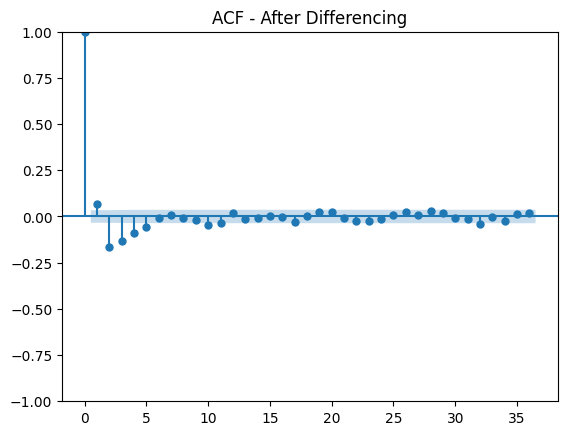

<Figure size 1200x500 with 0 Axes>

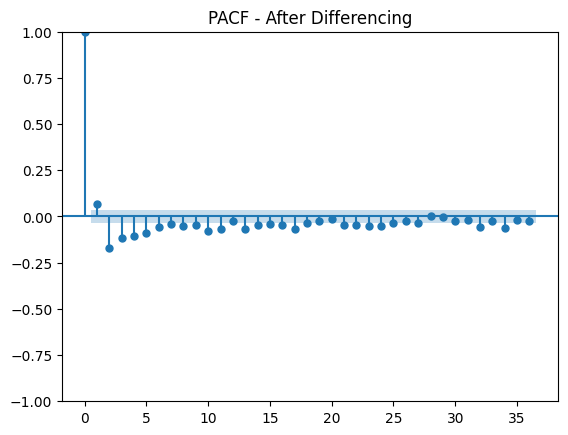

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plot_acf(y_final)
plt.title("ACF - After Differencing")
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(y_final, method="ywm")
plt.title("PACF - After Differencing")
plt.show()


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import boxcox

y = df["BASEL_temp_mean"]
y_shift = y - y.min() + 1
y_bc, lam = boxcox(y_shift)
y_bc = pd.Series(y_bc, index=df.index)

print("lambda =", lam)


lambda = 1.0143088545347747


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
best_aic = np.inf
best_order = None
best_model = None

ps = range(0,3)
qs = range(0,3)
d = 1

for p in ps:
    for q in qs:
        try:
            mod = SARIMAX(y_bc, order=(p,d,q), enforce_stationarity=False, enforce_invertibility=False)
            res = mod.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = (p,d,q)
                best_model = res
            print(f"tested order {(p,d,q)} AIC={res.aic:.1f}")
        except Exception as e:
            print(f"order {(p,d,q)} failed:", e)

print("BEST order:", best_order, "AIC:", best_aic)


tested order (0, 1, 0) AIC=16356.8
tested order (0, 1, 1) AIC=16325.6
tested order (0, 1, 2) AIC=16229.8
tested order (1, 1, 0) AIC=16338.4
tested order (1, 1, 1) AIC=16303.4
tested order (1, 1, 2) AIC=16064.2
tested order (2, 1, 0) AIC=16234.3
tested order (2, 1, 1) AIC=16072.5
tested order (2, 1, 2) AIC=16065.1
BEST order: (1, 1, 2) AIC: 16064.20481830032


In [ ]:
order = best_order if best_order is not None else (1,1,2)
model = SARIMAX(y_bc, order=order, enforce_stationarity=False, enforce_invertibility=False)
res = model.fit(disp=False)
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 3654
Model:               SARIMAX(1, 1, 2)   Log Likelihood               -8028.102
Date:                Wed, 19 Nov 2025   AIC                          16064.205
Time:                        10:46:26   BIC                          16089.015
Sample:                    01-01-2000   HQIC                         16073.040
                         - 01-01-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6696      0.027     24.848      0.000       0.617       0.722
ma.L1         -0.6431      0.029    -22.302      0.000      -0.700      -0.587
ma.L2         -0.2286      0.018    -13.005      0.0

In [ ]:
steps = 30

pred_bc = res.get_forecast(steps=steps)
pred_mean_bc = pred_bc.predicted_mean
pred_ci_bc = pred_bc.conf_int()

def inv_boxcox(y_bc_vals, lam):
    y_bc_vals = np.asarray(y_bc_vals)
    if np.isclose(lam, 0):
        return np.exp(y_bc_vals)
    else:
        return np.power(y_bc_vals * lam + 1, 1/lam)

pred_mean_orig = inv_boxcox(pred_mean_bc, lam)
pred_mean_orig = pred_mean_orig - 1 + y.min()

lower_bc = pred_ci_bc.iloc[:,0]
upper_bc = pred_ci_bc.iloc[:,1]
lower_orig = inv_boxcox(lower_bc, lam) - 1 + y.min()
upper_orig = inv_boxcox(upper_bc, lam) - 1 + y.min()

forecast_index = pd.date_range(start=y.index[-1] + pd.Timedelta(days=1), periods=steps, freq='D')
forecast_df = pd.DataFrame({
    "forecast": pred_mean_orig,
    "ci_lower": lower_orig,
    "ci_upper": upper_orig
}, index=forecast_index)

print(forecast_df.head())
forecast_df.to_csv("forecast_basel_temp_mean_arima.csv")

            forecast  ci_lower   ci_upper
2010-01-02  2.333979 -1.801914   6.450225
2010-01-03  2.511325 -3.422461   8.404499
2010-01-04  2.630058 -4.201459   9.407599
2010-01-05  2.709555 -4.674032  10.029946
2010-01-06  2.762782 -5.004207  10.459683
Saved forecast at /mnt/data/forecast_basel_temp_mean_arima.csv


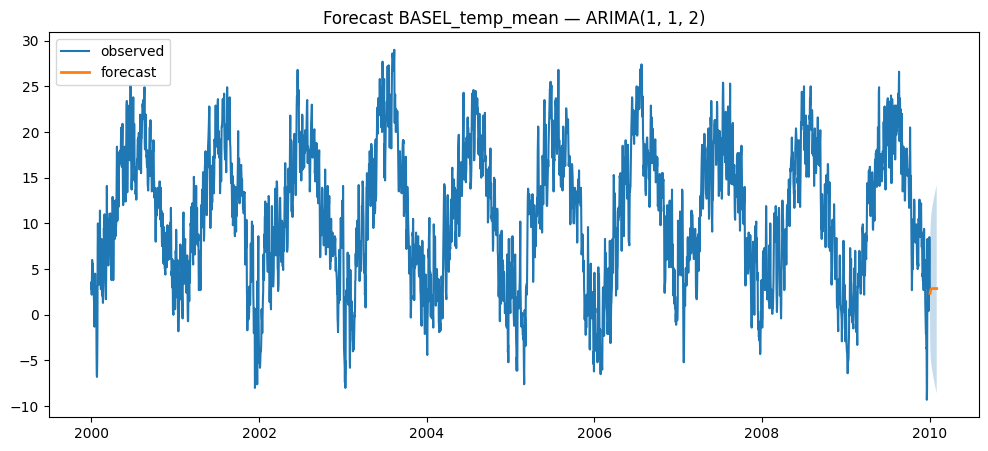

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y, label="observed")
plt.plot(forecast_df["forecast"], label="forecast", linewidth=2)
plt.fill_between(forecast_df.index, forecast_df["ci_lower"], forecast_df["ci_upper"], alpha=0.25)
plt.legend()
plt.title(f"Forecast BASEL_temp_mean — ARIMA{order}")
plt.show()
